None
Index(['ID', 'Identifier', 'ShortName', 'LongName', 'Domain', 'wkt',
       'geometry'],
      dtype='object')


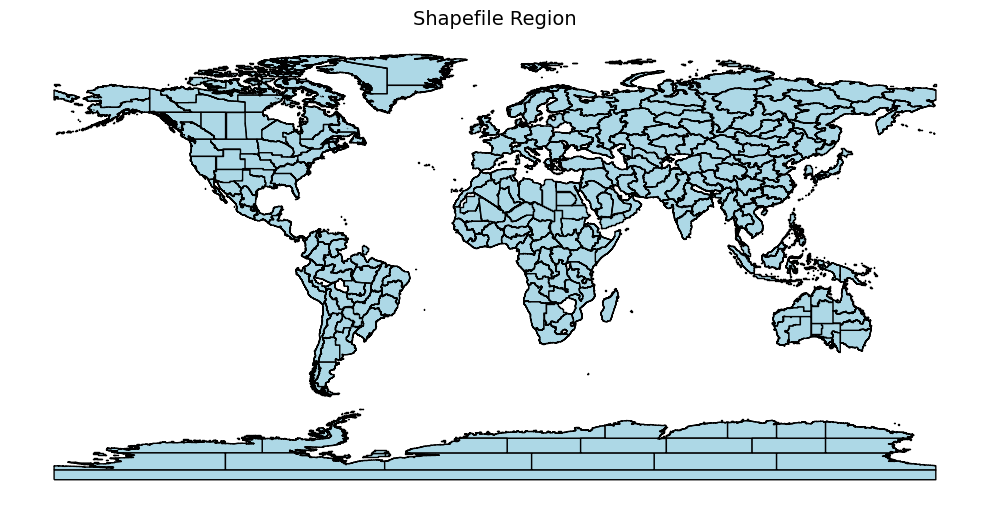

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 读取 shapefile（只需要提供 .shp 文件路径，其他文件会自动关联）
shapefile_path = 'region_fx-WRAF05-v4-1_WRAF_All-Hist_est1_v4-1_4-1-0_000000-000000.shp'  # 替换为你的文件路径
gdf = gpd.read_file(shapefile_path)

# 打印基本信息
print(gdf.crs)        # 查看坐标参考系统
print(gdf.columns)    # 查看属性字段（可以找到区域名字段）

# 绘图
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue')

# 可选：添加区域名称（假设字段名为 'NAME'，你可以换成实际的）
if 'NAME' in gdf.columns:
    gdf.apply(lambda x: ax.annotate(text=x['NAME'], xy=(x.geometry.centroid.x, x.geometry.centroid.y),
                                     ha='center', fontsize=8), axis=1)

# 设置标题与坐标
ax.set_title('Shapefile Region', fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("Region02.png", dpi=300, bbox_inches='tight')
plt.show()


In [5]:
import geopandas as gpd
import xarray as xr
import numpy as np
from rasterio import features
from affine import Affine

# -------------------------
# 1. 读取 shapefile
# -------------------------
shapefile_path = "region_fx-WRAF05-v4-1_WRAF_All-Hist_est1_v4-1_4-1-0_000000-000000.shp"  # 替换为你的文件名
gdf = gpd.read_file(shapefile_path)

# 假设区域字段是 'region_id' 或 'ID'，请确认字段名
if 'region_id' not in gdf.columns:
    gdf['region_id'] = np.arange(len(gdf))  # 如果没有就自动编号

# -------------------------
# 2. 创建网格（纬度-89.5~89.5，经度-179.5~179.5，共 180×360）
# -------------------------
res = 1.0  # 分辨率（度）
lon = np.arange(-179.5, 180, res)
lat = np.arange(-89.5, 90, res)
ny, nx = len(lat), len(lon)

# 创建变换矩阵：从行列号 → 经纬度
transform = Affine.translation(lon[0] - res/2, lat[0] - res/2) * Affine.scale(res, res)

# -------------------------
# 3. 栅格化
# -------------------------
shapes = ((geom, value) for geom, value in zip(gdf.geometry, gdf['region_id']))
raster = features.rasterize(
    shapes=shapes,
    out_shape=(ny, nx),
    transform=transform,
    fill=np.nan,
    dtype='float32'
)

# -------------------------
# 4. 转为 xarray 并保存为 nc
# -------------------------
ds = xr.Dataset(
    {"region_id": (("latitude", "longitude"), raster)},
    coords={"latitude": lat, "longitude": lon}
)

ds.to_netcdf("region_mask_1deg.nc")
print("✅ 保存成功：region_mask_1deg.nc")


✅ 保存成功：region_mask_1deg.nc


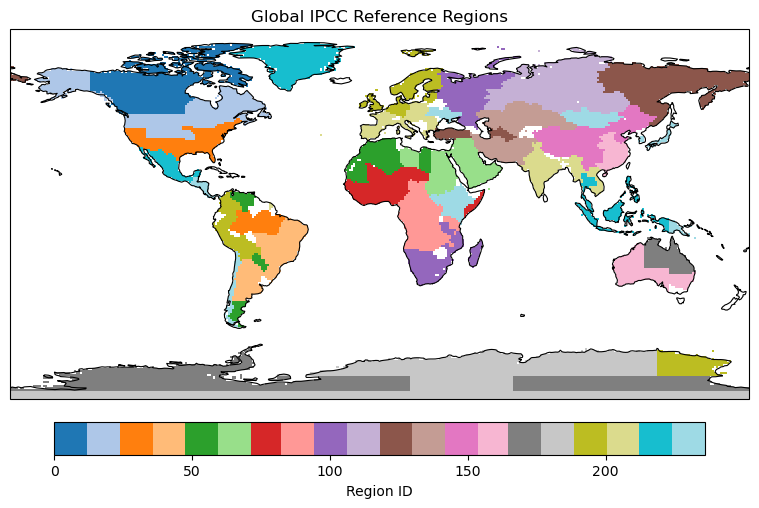

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. 读取 region_grid.nc
region_ds = xr.open_dataset("region_mask_1deg.nc")
region_data = region_ds["region_id"]

# 2. 获取经纬度
lat = region_data.latitude
lon = region_data.longitude

# 3. 生成唯一区域 ID 并映射到整数颜色
unique_regions, region_indices = np.unique(region_data, return_inverse=True)
region_grid_colored = region_indices.reshape(region_data.shape)

# 4. 绘制地图
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_global()

# 添加海岸线
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")

# 绘制区域数据
cmap = plt.get_cmap("tab20", len(unique_regions))  # 使用 tab20 颜色映射
region_grid_colored_masked = np.ma.masked_where(np.isnan(region_data), region_grid_colored)
mesh = ax.pcolormesh(lon, lat, region_grid_colored_masked, cmap=cmap, shading="auto")

# 添加颜色条
cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, shrink=0.7)
cbar.set_label("Region ID")

# 显示
plt.title("Global IPCC Reference Regions")
plt.show()


EPSG:4326
Index(['FIPS', 'ISO2', 'ISO3', 'UN', 'NAME', 'AREA', 'POP2005', 'REGION',
       'SUBREGION', 'LON', 'LAT', 'geometry'],
      dtype='object')


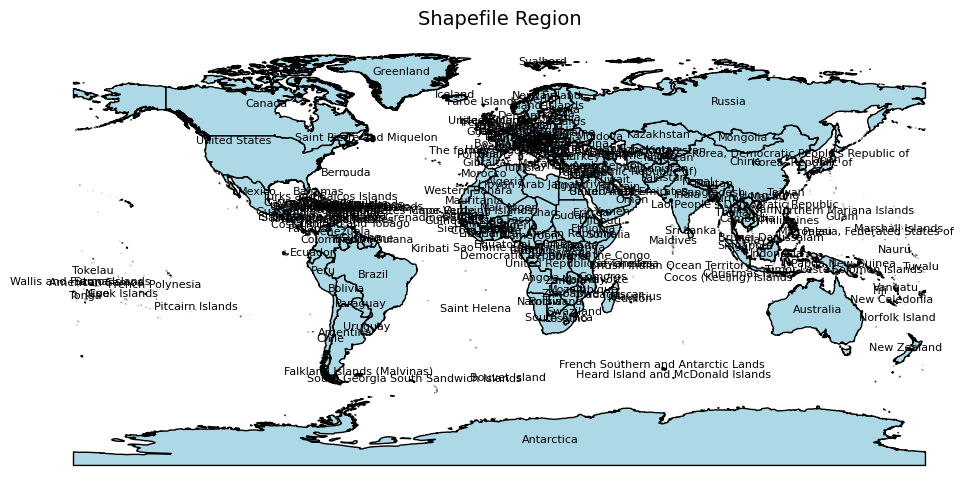

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 读取 shapefile（只需要提供 .shp 文件路径，其他文件会自动关联）
shapefile_path = 'world_border/TM_WORLD_BORDERS-0.3.shp'  # 替换为你的文件路径
gdf = gpd.read_file(shapefile_path)

# 打印基本信息
print(gdf.crs)        # 查看坐标参考系统
print(gdf.columns)    # 查看属性字段（可以找到区域名字段）

# 绘图
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue')

# 可选：添加区域名称（假设字段名为 'NAME'，你可以换成实际的）
if 'NAME' in gdf.columns:
    gdf.apply(lambda x: ax.annotate(text=x['NAME'], xy=(x.geometry.centroid.x, x.geometry.centroid.y),
                                     ha='center', fontsize=8), axis=1)

# 设置标题与坐标
ax.set_title('Shapefile Region', fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("Region02.png", dpi=300, bbox_inches='tight')
plt.show()


In [3]:
import geopandas as gpd
import xarray as xr
import numpy as np
from rasterio import features
from affine import Affine

# -------------------------
# 1. 读取 shapefile
# -------------------------
shapefile_path = "world_border/TM_WORLD_BORDERS-0.3.shp"  # 替换为你的文件名
gdf = gpd.read_file(shapefile_path)

# 假设区域字段是 'region_id' 或 'ID'，请确认字段名
if 'region_id' not in gdf.columns:
    gdf['region_id'] = np.arange(len(gdf))  # 如果没有就自动编号

# -------------------------
# 2. 创建网格（纬度-89.5~89.5，经度-179.5~179.5，共 180×360）
# -------------------------
res = 1.0  # 分辨率（度）
lon = np.arange(-179.5, 180, res)
lat = np.arange(-89.5, 90, res)
ny, nx = len(lat), len(lon)

# 创建变换矩阵：从行列号 → 经纬度
transform = Affine.translation(lon[0] - res/2, lat[0] - res/2) * Affine.scale(res, res)

# -------------------------
# 3. 栅格化
# -------------------------
shapes = ((geom, value) for geom, value in zip(gdf.geometry, gdf['region_id']))
raster = features.rasterize(
    shapes=shapes,
    out_shape=(ny, nx),
    transform=transform,
    fill=np.nan,
    dtype='float32'
)

# -------------------------
# 4. 转为 xarray 并保存为 nc
# -------------------------
ds = xr.Dataset(
    {"region_id": (("latitude", "longitude"), raster)},
    coords={"latitude": lat, "longitude": lon}
)

ds.to_netcdf("border_mask_1deg.nc")
print("✅ 保存成功：border_mask_1deg.nc")


✅ 保存成功：border_mask_1deg.nc


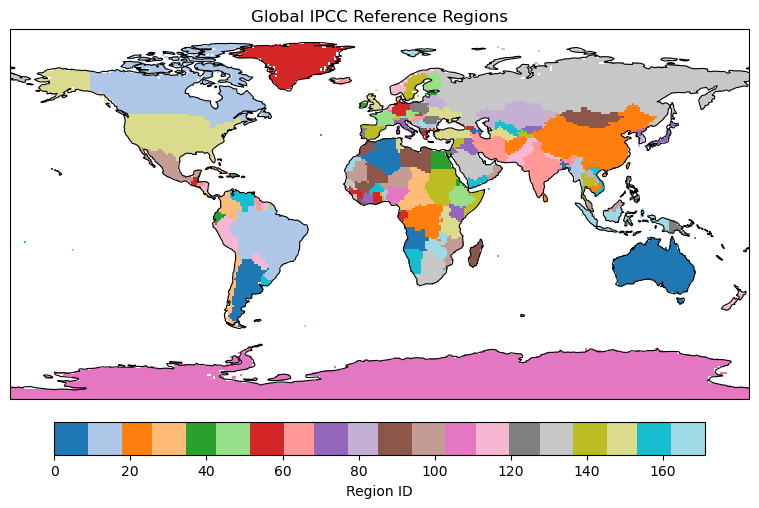

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. 读取 region_grid.nc
region_ds = xr.open_dataset("border_mask_1deg_One_China.nc")
region_data = region_ds["region_id"]

# 2. 获取经纬度
lat = region_data.latitude
lon = region_data.longitude

# 3. 生成唯一区域 ID 并映射到整数颜色
unique_regions, region_indices = np.unique(region_data, return_inverse=True)
region_grid_colored = region_indices.reshape(region_data.shape)

# 4. 绘制地图
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_global()

# 添加海岸线
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black")

# 绘制区域数据
cmap = plt.get_cmap("tab20", len(unique_regions))  # 使用 tab20 颜色映射
region_grid_colored_masked = np.ma.masked_where(np.isnan(region_data), region_grid_colored)
mesh = ax.pcolormesh(lon, lat, region_grid_colored_masked, cmap=cmap, shading="auto")

# 添加颜色条
cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, shrink=0.7)
cbar.set_label("Region ID")

# 显示
plt.title("Global IPCC Reference Regions")
plt.savefig("border_regions.png", dpi=300, bbox_inches="tight")  # 可改为 .pdf, .svg 等格式
plt.show()


In [5]:
import xarray as xr
import numpy as np

ds = xr.open_dataset('border_mask_1deg_One_China.nc')
region_ids = ds['region_id'].values  # 转成numpy数组
unique_ids = np.unique(region_ids)   # 找唯一值

print("Unique region_id count:", len(unique_ids))
print("Unique region_id values:", unique_ids)



Unique region_id count: 173
Unique region_id values: [  1.   2.   3.   4.   5.   7.   8.  13.  14.  15.  16.  17.  18.  19.
  20.  21.  22.  23.  24.  25.  26.  27.  28.  29.  30.  31.  32.  34.
  35.  37.  38.  39.  40.  44.  45.  47.  48.  49.  50.  51.  52.  53.
  54.  55.  56.  57.  58.  59.  60.  61.  63.  64.  65.  66.  67.  68.
  70.  71.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  90.  91.  92.  93.  95.  96.  97.  98.  99. 100.
 101. 102. 103. 104. 106. 107. 109. 111. 112. 113. 114. 115. 117. 119.
 120. 121. 122. 123. 125. 128. 132. 138. 139. 144. 146. 151. 152. 153.
 154. 155. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167. 170.
 171. 172. 174. 175. 176. 179. 180. 181. 182. 183. 184. 186. 187. 189.
 190. 191. 192. 194. 195. 198. 200. 201. 203. 204. 205. 206. 207. 208.
 209. 210. 211. 213. 215. 217. 219. 220. 221. 222. 223. 224. 227. 228.
 236. 237. 239. 244.  nan]


In [12]:
%pwd

'/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/0.5Million KM2'